# Gold standard experiment comparison

Description Extraction Calibration results are compared for three models. For each model, the original experiment, `-r2`, and `-r3` are grouped as three repetitions of the same experiment.

One summary row and one bar per metric are shown for each model. The mean across the three run means is shown by the bar height; the minimum and maximum run means are shown by the interval.

In [17]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from bson.decimal128 import Decimal128
from IPython.display import display
from pymongo import MongoClient

MODE = "full"  # The short dataset can be selected with "short".
MODELS = {
    "gemini-3-5-flash-lite": "Gemini 3.5 Flash Lite",
    "glm-5-3-flash": "GLM-5.3 Flash",
    "gpt5-6-luna": "GPT-5.6 Luna",
}
EXPERIMENTS = {
    base + ("" if run == 1 else f"-r{run}"): (model, run)
    for base, model in MODELS.items()
    for run in (1, 2, 3)
}
MODEL_COLORS = {
    "Gemini 3.5 Flash Lite": "#d62728",
    "GLM-5.3 Flash": "#ff7f0e",
    "GPT-5.6 Luna": "#1f77b4",
}
METRICS = {
    "semantic_f1_score": "Semantic F1 ↑",
    "semantic_precision": "Semantic precision ↑",
    "completeness_rate": "Completeness rate ↑",
    "redundancy_rate": "Redundancy rate ↓",
    "syntactic_error_rate": "Syntactic error rate ↓",
    "naming_understandability_score": "Naming understandability ↑",
    "reference_complexity": "Reference complexity",
    "candidate_complexity": "Candidate complexity",
    "complexity_difference": "Complexity difference (ideal: 0)",
    "complexity_deviation_rate": "Complexity deviation rate ↓",
}
MONGODB_URI = os.getenv(
    "MONGODB_URI",
    "mongodb://127.0.0.1:27017/llm_uml_evaluator?replicaSet=rs0",
)
plt.style.use("seaborn-v0_8-whitegrid")

## Data loading

Observations are read from `gold_standard_eval`. The URI is read from `MONGODB_URI`; JupyterLab is started with `uv run --env-file .env --group eval jupyter lab`. A single dataset mode is selected with `MODE` so that short and full runs are not mixed. Only stored metrics and observation identifiers are loaded.

In [18]:
if MODE not in {"short", "full"}:
    raise ValueError("MODE must be 'short' or 'full'")

client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5_000)
try:
    documents = list(client.get_default_database()["gold_standard_eval"].find(
        {"experiment_name": {"$in": list(EXPERIMENTS)}, "mode": MODE},
        {"experiment_name": 1, "sample": 1, "mode": 1,
         "metrics.candidate_is_allowed": 1,
         **{f"metrics.{metric}": 1 for metric in METRICS}},
    ))
finally:
    client.close()

loaded = {document["experiment_name"] for document in documents}
if missing := set(EXPERIMENTS) - loaded:
    raise ValueError(f"No observations for mode={MODE}: {sorted(missing)}")

df = pd.json_normalize(documents).rename(columns={
    f"metrics.{name}": name
    for name in [*METRICS, "candidate_is_allowed"]
})
required = {"experiment_name", "sample", "candidate_is_allowed", *METRICS}
if missing := required - set(df.columns):
    raise ValueError(f"Missing columns: {sorted(missing)}")
if df[list(required)].isna().any().any():
    raise ValueError("Missing observation identifiers or metric values")
if df.duplicated(["experiment_name", "sample"]).any():
    raise ValueError("Duplicate samples within an experiment")

df["model"] = df["experiment_name"].map(lambda name: EXPERIMENTS[name][0])
df["run"] = df["experiment_name"].map(lambda name: EXPERIMENTS[name][1])
for metric in METRICS:
    df[metric] = df[metric].map(
        lambda value: float(
            value.to_decimal() if isinstance(value, Decimal128) else value
        )
    )
if df[list(METRICS)].isna().any().any():
    raise ValueError("NaN metric values cannot be compared")

## Coverage check

The number of observations, disallowed candidates, and missing samples is shown for each experiment. Comparisons are stopped if sample sets differ across runs; otherwise, every run is compared on the same samples. Incomplete but identical sample sets are reported with a warning. Disallowed candidates are retained with their stored scores.

In [19]:
expected_samples = set(range(1, 61) if MODE == "full" else (1, 11, 21, 31, 41, 51))
sample_sets = df.groupby("experiment_name")["sample"].agg(set)
coverage = pd.DataFrame({
    "model": {name: model for name, (model, run) in EXPERIMENTS.items()},
    "run": {name: run for name, (model, run) in EXPERIMENTS.items()},
    "observations": df.groupby("experiment_name").size(),
    "disallowed_candidates": df.groupby("experiment_name")[
        "candidate_is_allowed"
    ].agg(lambda values: (~values.astype(bool)).sum()),
    "missing_samples": sample_sets.map(lambda samples: sorted(expected_samples - samples)),
}).reindex(EXPERIMENTS)
display(coverage)
if any(samples - expected_samples for samples in sample_sets):
    raise ValueError("Unexpected sample identifiers for the selected mode")
if any(samples != sample_sets.iloc[0] for samples in sample_sets):
    raise ValueError("Sample coverage differs; complete the runs before comparison")
if sample_sets.iloc[0] != expected_samples:
    warnings.warn("All runs share an incomplete sample set; results cover only these samples.")

,model,run,observations,disallowed_candidates,missing_samples
gemini-3-5-flash-lite,Gemini 3.5 Flash Lite,1,60,0,[]
gemini-3-5-flash-lite-r2,Gemini 3.5 Flash Lite,2,60,0,[]
gemini-3-5-flash-lite-r3,Gemini 3.5 Flash Lite,3,60,0,[]
glm-5-3-flash,GLM-5.3 Flash,1,60,0,[]
glm-5-3-flash-r2,GLM-5.3 Flash,2,60,0,[]
glm-5-3-flash-r3,GLM-5.3 Flash,3,60,0,[]
gpt5-6-luna,GPT-5.6 Luna,1,60,0,[]
gpt5-6-luna-r2,GPT-5.6 Luna,2,60,0,[]
gpt5-6-luna-r3,GPT-5.6 Luna,3,60,0,[]


## Metrics by model

Stored per-diagram metrics are first averaged within each run (macro averaging), and the three run means are then averaged with equal weight for each model. Because identical sample coverage is required, this is also equal to the mean across all observations for that model. Semantic F1 is averaged from stored scores, rather than recomputed from averaged precision and completeness.

The number of distinct samples, runs, and total observations is reported separately: 180 observations from three full runs represent 60 distinct samples. Disallowed candidates are retained.

Naming understandability is kept on its stored 0–3 scale. Complexity deviation is unbounded and can be infinite when reference complexity is zero and candidate complexity is positive. Infinite values are retained and counted explicitly; they are never replaced by zero or excluded from the mean.

In [20]:
run_means = df.groupby("experiment_name")[list(METRICS)].mean().reindex(EXPERIMENTS)
# Infinite deviations are retained explicitly across pandas versions.
infinite_counts = df.groupby("experiment_name")["complexity_deviation_rate"].agg(
    lambda values: values.eq(float("inf")).sum()
).reindex(EXPERIMENTS)
run_means.loc[infinite_counts.gt(0), "complexity_deviation_rate"] = float("inf")
run_means["model"] = run_means.index.map(lambda name: EXPERIMENTS[name][0])
model_stats = run_means.groupby("model")[list(METRICS)].agg(
    ["mean", "min", "max"]
).reindex(MODELS.values())
infinite_by_model = df.assign(
    infinite_deviation=df["complexity_deviation_rate"].eq(float("inf"))
).groupby("model")["infinite_deviation"].sum()
model_stats.loc[
    infinite_by_model.reindex(model_stats.index).gt(0),
    ("complexity_deviation_rate", "mean"),
] = float("inf")
summary = df.groupby("model").agg(
    runs=("run", "nunique"),
    samples=("sample", "nunique"),
    observations=("sample", "size"),
    allowed_candidate_rate=("candidate_is_allowed", "mean"),
).reindex(MODELS.values())
summary = summary.join(model_stats.xs("mean", axis=1, level=1))
summary["infinite_deviations"] = infinite_by_model
display(summary.round(4))

,runs,samples,observations,allowed_candidate_rate,semantic_f1_score,semantic_precision,completeness_rate,redundancy_rate,syntactic_error_rate,naming_understandability_score,reference_complexity,candidate_complexity,complexity_difference,complexity_deviation_rate,infinite_deviations
model,,,,,,,,,,,,,,,
Gemini 3.5 Flash Lite,3,60,180,1.0,0.7022,0.8532,0.6148,0.1468,0.0001,2.9972,89.3,56.2333,-33.0667,0.3595,0
GLM-5.3 Flash,3,60,180,1.0,0.6943,0.8134,0.6276,0.1866,0.0087,2.9832,89.3,64.7556,-24.5444,0.3167,0
GPT-5.6 Luna,3,60,180,1.0,0.7363,0.8040,0.7017,0.1960,0.0002,2.9883,89.3,74.0667,-15.2333,0.2560,0


## Quality by model

Six metric panels are used so that different scales and preferred directions can be read separately. Higher values are preferred for metrics marked ↑; lower values are preferred for metrics marked ↓.

For each model, the mean of the three run means is shown as one vertical bar. The minimum and maximum run means are shown as a vertical interval. These intervals describe between-run variation; they are not confidence intervals and do not describe the spread across individual diagrams.

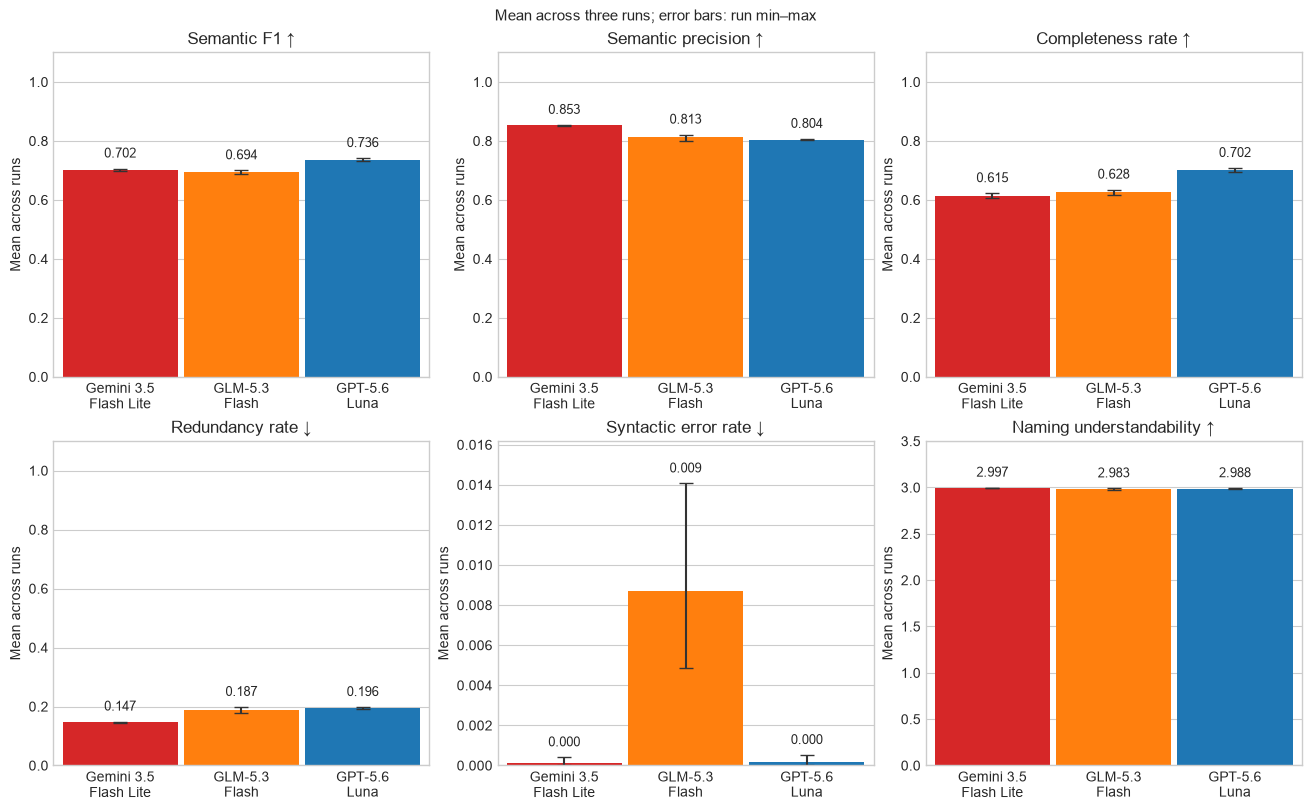

In [25]:
def plot_model_means(metric_names, columns=3):
    rows = (len(metric_names) + columns - 1) // columns
    fig, axes = plt.subplots(
        rows, columns, figsize=(13, 4 * rows), squeeze=False,
        constrained_layout=True,
    )
    model_labels = ["Gemini 3.5\nFlash Lite", "GLM-5.3\nFlash", "GPT-5.6\nLuna"]
    for ax, metric in zip(axes.flat, metric_names):
        for x, model in enumerate(MODELS.values()):
            mean, minimum, maximum = model_stats.loc[
                model, [(metric, "mean"), (metric, "min"), (metric, "max")]
            ]
            if maximum == float("inf"):
                ax.text(
                    x, 0.95, "Mean / max: ∞",
                    transform=ax.get_xaxis_transform(), ha="center",
                    va="top", color=MODEL_COLORS[model],
                )
            else:
                ax.bar(
                    x, mean, width=0.95,
                    yerr=[[mean - minimum], [maximum - mean]],
                    color=MODEL_COLORS[model], capsize=5,
                    error_kw={"ecolor": "#333333", "elinewidth": 1.5},
                )
                ax.annotate(
                    f"{mean:.3f}",
                    (x, maximum if mean >= 0 else minimum),
                    xytext=(0, 6 if mean >= 0 else -6),
                    textcoords="offset points", ha="center",
                    va="bottom" if mean >= 0 else "top", fontsize=9,
                )
        ax.set(
            title=METRICS[metric], ylabel="Mean across runs",
            xticks=range(len(MODELS)), xticklabels=model_labels,
            xlim=(-0.55, len(MODELS) - 0.45),
        )
        ax.grid(axis="x", visible=False)
        ax.margins(y=0.15)
        if metric == "naming_understandability_score":
            ax.set_ylim(0, 3.5)
        elif metric in list(METRICS)[:4]:
            ax.set_ylim(0, 1.1)
        elif metric == "complexity_difference":
            ax.axhline(0, color="gray", linewidth=1)
        else:
            ax.set_ylim(bottom=0)
    for ax in list(axes.flat)[len(metric_names):]:
        ax.set_visible(False)
    fig.suptitle("Mean across three runs; error bars: run min–max", fontsize=11)
    return fig

quality_figure = plot_model_means(list(METRICS)[:6])
plt.show()

## Complexity by model

Candidate complexity, signed complexity difference, and absolute proportional complexity deviation are shown separately. Positive differences indicate greater candidate complexity; negative differences indicate lower candidate complexity. Opposing signed differences can cancel in the mean, so deviation is also shown. Infinite means and maxima are annotated as ∞ instead of being plotted at a finite coordinate. Reference complexity is available in the table above. Intervals span the minimum and maximum of the three run means.

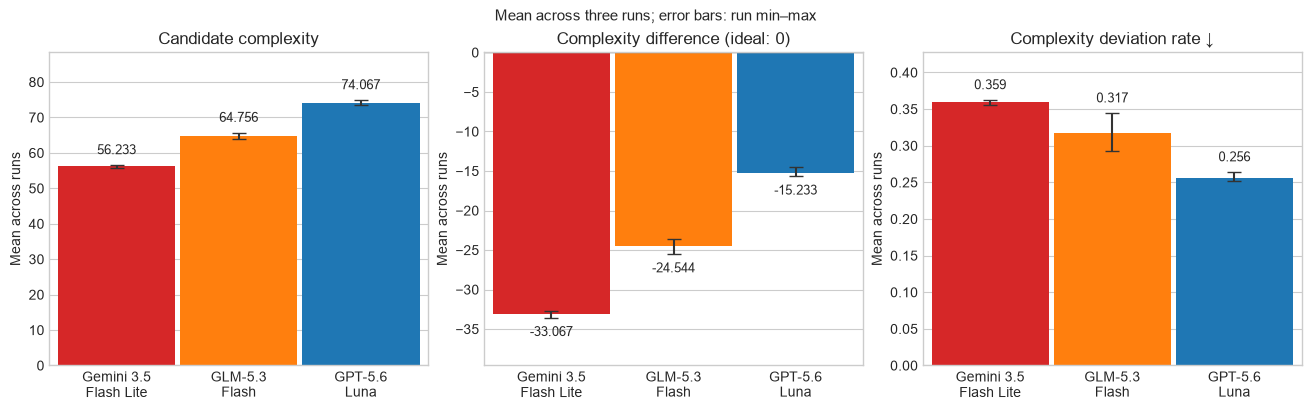

In [6]:
complexity_figure = plot_model_means([
    "candidate_complexity", "complexity_difference", "complexity_deviation_rate",
])
plt.show()